####  EXPLORATORY DATA ANALYSIS 

In [58]:
import pandas as pd

In [59]:
df = pd.read_csv('Crop_recommendation.csv')

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


In [61]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [62]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [63]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [64]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [65]:
df.shape

(2200, 8)

In [66]:
df.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [67]:
df['label'].unique()

<ArrowStringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

Handling missing data + outliers

In [68]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [69]:
(df == 0).sum()

N              27
P               0
K               0
temperature     0
humidity        0
ph              0
rainfall        0
label           0
dtype: int64

In [70]:
df[df['N'] == 0]['label'].value_counts()

label
lentil         4
orange         4
coconut        4
pomegranate    3
mango          3
apple          3
kidneybeans    2
pigeonpeas     1
mothbeans      1
mungbean       1
grapes         1
Name: count, dtype: int64

In [71]:
df = df[df['N']!=0]

In [72]:
print(2200 - len(df))

27


In [73]:
(df == 0).sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [74]:
Q1 = df['N'].quantile(0.25)

In [75]:
Q3 = df['N'].quantile(0.75)

In [76]:
IQR = Q3-Q1

In [77]:
lower = Q1 - 1.5*IQR
upper = Q3 - 1.5*IQR

In [78]:
df_clean = df[(df['N'] >= lower) & (df['N'] <= upper)]

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

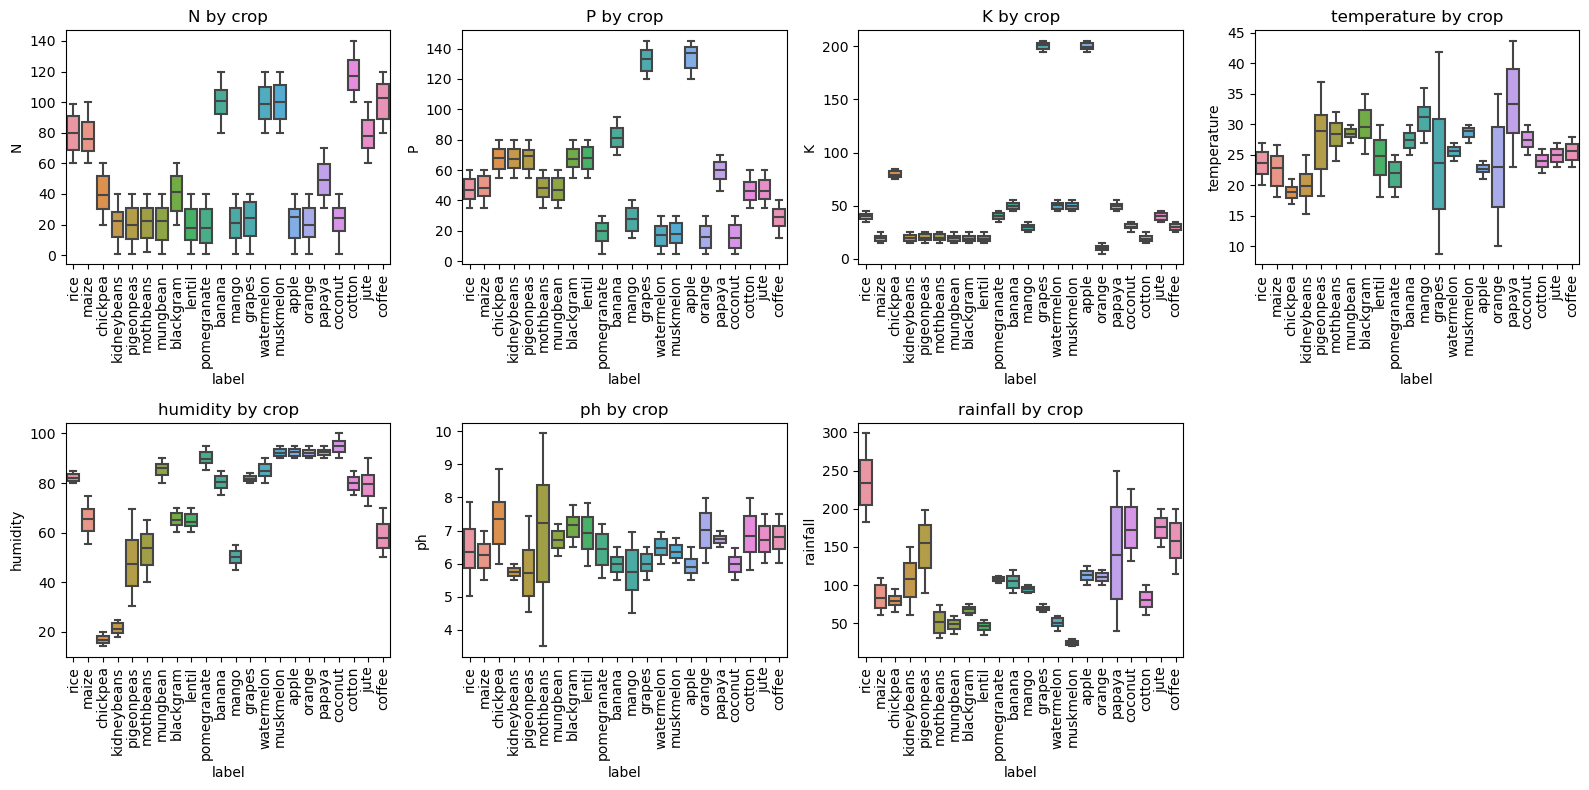

In [80]:
features = ['N','P','K','temperature','humidity','ph','rainfall']

fig, axes = plt.subplots(2,4, figsize=(16,8))
axes = axes.flatten()

for i,features in enumerate(features):
    sns.boxplot(data = df, x='label', y=features, ax=axes[i])
    axes[i].set_title(f'{features} by crop')
    axes[i].tick_params(axis='x',rotation=90)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150)
plt.show()

Feature engineering - label encoding, scaling, test_train_split

In [81]:
from sklearn.preprocessing import LabelEncoder

In [82]:
LE = LabelEncoder()
df['crop_encoded'] = LE.fit_transform(df['label'])

In [83]:
mapping = dict(zip(LE.classes_, LE.transform(LE.classes_)))
print(mapping)

{'apple': 0, 'banana': 1, 'blackgram': 2, 'chickpea': 3, 'coconut': 4, 'coffee': 5, 'cotton': 6, 'grapes': 7, 'jute': 8, 'kidneybeans': 9, 'lentil': 10, 'maize': 11, 'mango': 12, 'mothbeans': 13, 'mungbean': 14, 'muskmelon': 15, 'orange': 16, 'papaya': 17, 'pigeonpeas': 18, 'pomegranate': 19, 'rice': 20, 'watermelon': 21}


In [84]:
import joblib

joblib.dump(LE, 'label_encoder.pkl')
print("saved label encoder")

saved label encoder


must save LE with joblib.dump because when your fastapi endpoint predicts 2, it needs the encoder to turn that back into 'blackgram'. if you dont save it, you will have to retrain just to decode outputs.

In [85]:
from sklearn.model_selection import train_test_split

In [86]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size: {X_train.shape}')
print(f"test_size: {X_test.shape}")


Train size: (1738, 7)
test_size: (435, 7)


In [87]:
#verify stratification
unique, train_counts = np.unique(y_train, return_counts=True)
_, test_counts= np.unique(y_test, return_counts=True)
for i, crop in enumerate(LE.classes_):
    print(f"{crop:15s} train:{train_counts[i]:4d} test: {test_counts[i]:3d}")

apple           train:  78 test:  19
banana          train:  80 test:  20
blackgram       train:  80 test:  20
chickpea        train:  80 test:  20
coconut         train:  77 test:  19
coffee          train:  80 test:  20
cotton          train:  80 test:  20
grapes          train:  79 test:  20
jute            train:  80 test:  20
kidneybeans     train:  78 test:  20
lentil          train:  77 test:  19
maize           train:  80 test:  20
mango           train:  78 test:  19
mothbeans       train:  79 test:  20
mungbean        train:  79 test:  20
muskmelon       train:  80 test:  20
orange          train:  77 test:  19
papaya          train:  80 test:  20
pigeonpeas      train:  79 test:  20
pomegranate     train:  77 test:  20
rice            train:  80 test:  20
watermelon      train:  80 test:  20


In [88]:
from sklearn.preprocessing import StandardScaler


In [97]:

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc = scaler.transform(X_test_raw)

print("means:", X_train_sc.mean(axis=0).round(3))

print("stds:", X_train_sc.std(axis=0).round(3) )

joblib.dump(scaler, 'scaler.pkl')
print("saved scaler")

means: [-0.  0. -0. -0. -0. -0.  0.]
stds: [1. 1. 1. 1. 1. 1. 1.]
saved scaler


Visualisations

In [90]:
import seaborn as sns

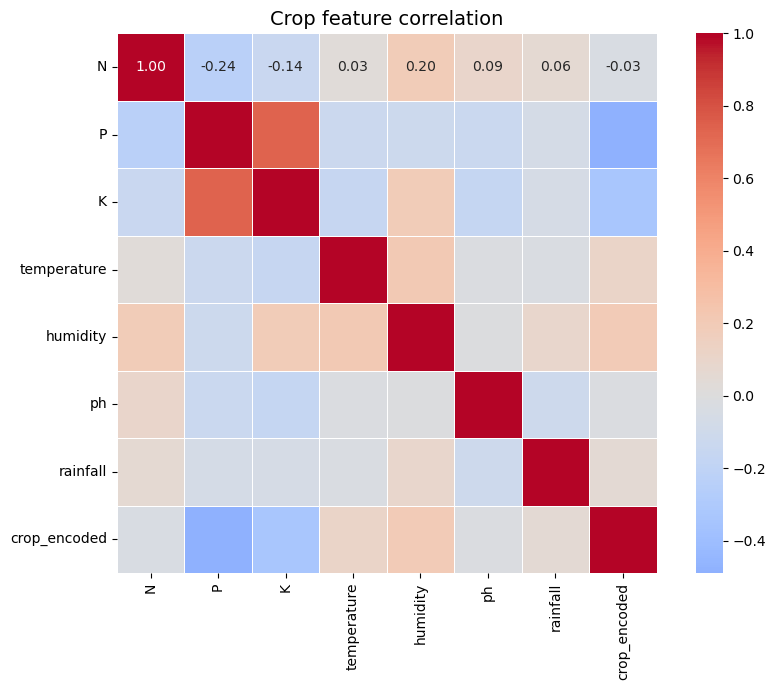

In [91]:
plt.figure(figsize=(9,7))
numeric_df = df.drop(columns=['label'])
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt ='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Crop feature correlation', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap.png',dpi=150)
plt.show()

Histogram for feature distribution per crop

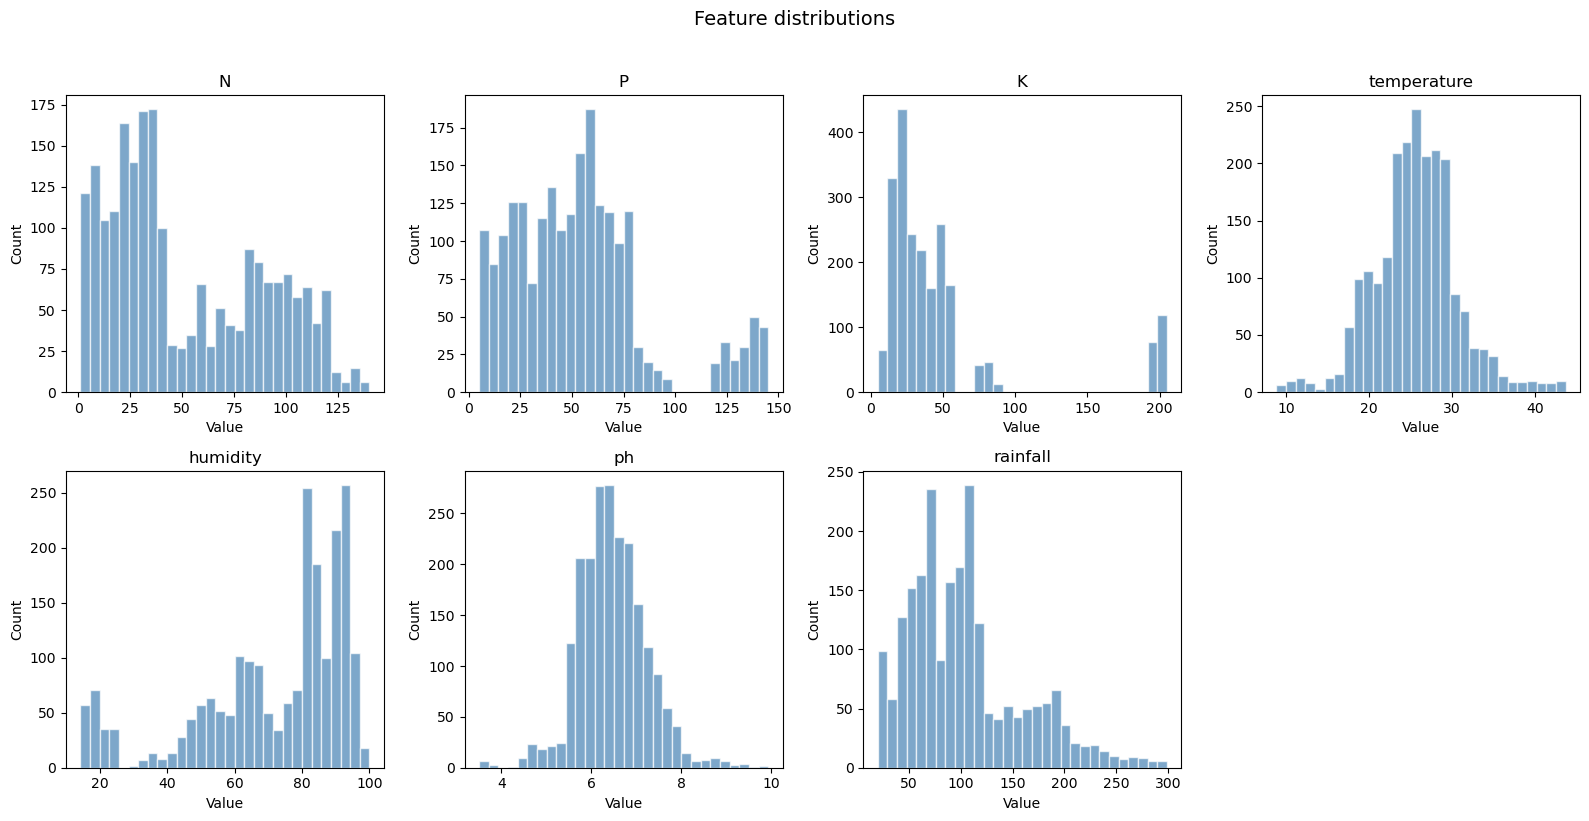

In [92]:
features = ['N','P','K','temperature','humidity','ph','rainfall']

fig, axes = plt.subplots(2,4, figsize=(16,8))
axes = axes.flatten()

for i,features in enumerate(features):
    axes[i].hist(df[features],bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].set_title(features,fontsize =12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Feature distributions', fontsize =14, y=1.02)
plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()

Boxplot- feature per crop
(picking top 6 crops so its readable)

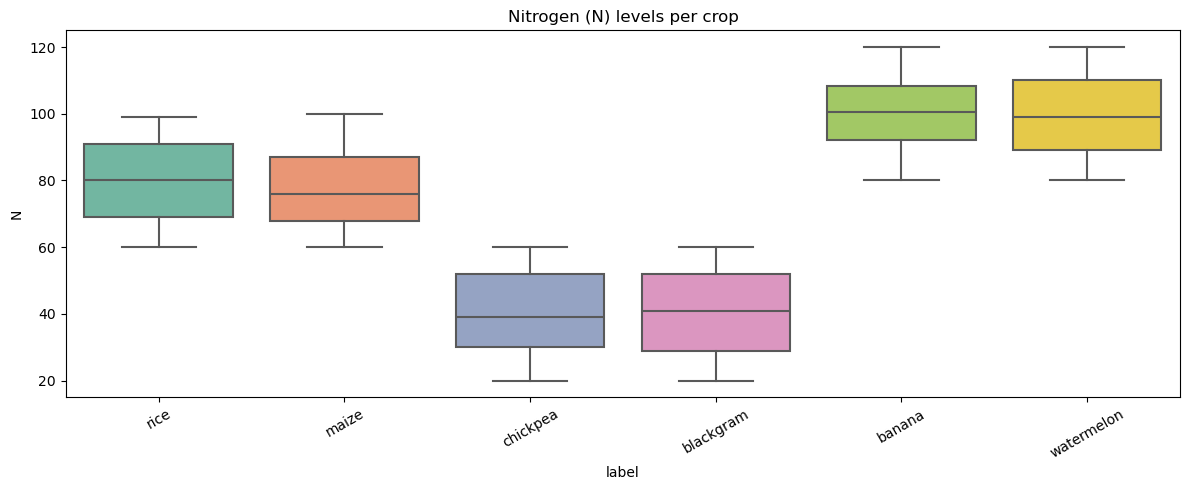

In [93]:
top_crops=df['label'].value_counts().head(6).index
df_top= df[df['label'].isin(top_crops)]

plt.figure(figsize=(12,5))
sns.boxplot(data=df_top, x ='label', y='N', palette='Set2')
plt.title('Nitrogen (N) levels per crop')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('boxplot_N.png', dpi = 120)
plt.show()

Pairplot of key features

In [94]:
# df_sample = df.sample(200, random_state=42)
# sns.pairplot(df_sample[['N','K','ph','rainfall','label']],
#             hue='label', plot_kws={'aplha': 0.5}, diag_kind='kde')
# plt.suptitle('Pairplot of key features', y= 1.02)
# plt.savefig('pairplot.png',dpi =120)
# plt.show()

Baseline models

In [98]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200, C=2.0, multi_class='auto')
lr.fit(X_train_sc,y_train)
print("LR Train accuracy:", round(lr.score(X_train_sc,y_train)*100,2), "%")
print("LR Test accuracy:", round(lr.score(X_test_sc,y_test)*100,2), "%")


LR Train accuracy: 97.81 %
LR Test accuracy: 96.78 %


train accuracy: 99.37 %
test accuracy: 98.85 %


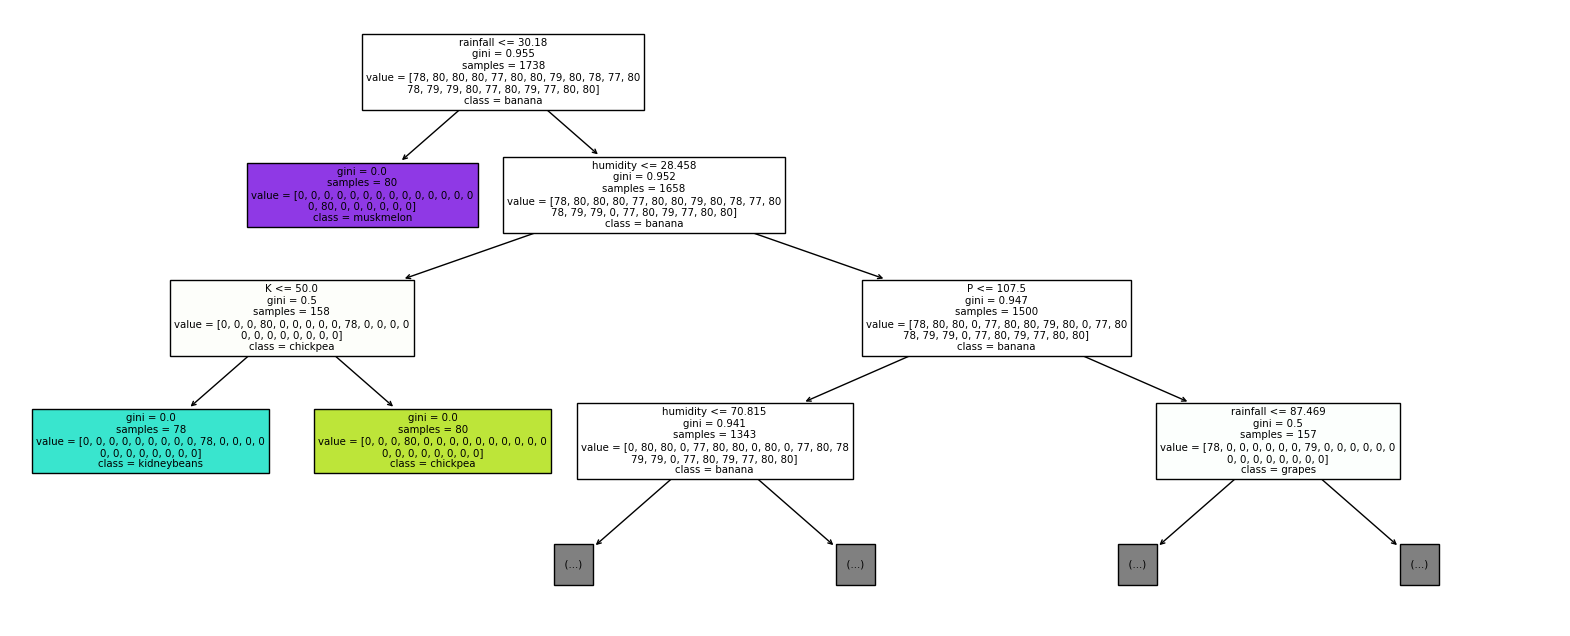

In [100]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=None,
    min_samples_leaf=5,
    criterion='gini',
    random_state=42
)

dt.fit(X_train_raw,y_train)   #no scaling needed for trees

print("train accuracy:", round(dt.score(X_train_raw,y_train)*100,2), "%")
print("test accuracy:", round(dt.score(X_test_raw,y_test)*100,2), "%")

feature_list=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

from sklearn.tree import plot_tree
plt.figure(figsize=(20,8))
plot_tree(dt,max_depth=3,feature_names=feature_list,
        class_names=LE.classes_, filled=True)
plt.savefig("decision_tree.png", dpi=100, bbox_inches='tight')
plt.show()
